Empirical Timescale Computation

In [1]:
# Imports
import numpy as np
from hbnm.io import Data
from hbnm.bnm import Bnm

In [2]:
"""
Set directories
"""
input_dir = "/home/frank/HBNM/data/"
output_dir = "/home/frank/HBNM/outputs/"

"""
Load data
"""
data = Data(input_dir, output_dir)
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() 

fin = data.load('demirtas_neuron_2019.hdf5', from_output=False)
theta_heterogeneous = fin['apprx_posterior_heterogeneous'][:]
theta_homogeneous = fin['apprx_posterior_homogeneous'][:]
fin.close()

# Define which particle to use (0 for first, 1 for second, etc.)
particle_idx = 1  # Change this index to select a different particle

# Homogeneous model

homogeneous = Bnm(sc)
homogeneous.set('w_EI', theta_homogeneous[0, particle_idx])
homogeneous.set('w_EE', theta_homogeneous[1, particle_idx])
homogeneous.set('G', theta_homogeneous[2, particle_idx])
# homogeneous.moments_method()

# Heterogeneous model

heterogeneous = Bnm(sc, gradient=hmap)
heterogeneous.set('w_EI', (theta_heterogeneous[0, particle_idx], theta_heterogeneous[1, particle_idx]))
heterogeneous.set('w_EE', (theta_heterogeneous[2, particle_idx], theta_heterogeneous[3, particle_idx]))
heterogeneous.set('G', theta_heterogeneous[4, particle_idx])
# heterogeneous.moments_method()

In [3]:
# Set up Numerical Simulation

# Define simulation parameters
total_time = 30.0
dt = 0.0001
n_save = 10
trials = 5
# n_regions = heterogeneous.dmf.nc

# Calculate time points
# n_timepoints = int(total_time / (dt * n_save)) + 1

# Pre-allocate 3D array: (trials, regions, timepoints)
# r_E_trials = np.zeros((trials, n_regions, n_timepoints))

In [4]:
# Numberical Simulation
heterogeneous.dmf.integrate(
    t=total_time,
    dt=dt,
    n_save=n_save,
    delays=False,
    include_BOLD=True,
    from_fixed=True,
    # sim_seed=trial_num
)

In [5]:
# After running the simulation, save the r_E data for Julia analysis
r_E_data = heterogeneous.dmf.sim.time_series('r_E')

# Cut off the first 10 seconds of the simulation
dt = 0.0001
n_save = 10
skip_seconds = 0.0
# Calculate how many timepoints to skip
skip_points = int(skip_seconds / (dt * n_save))
r_E_data_cut = r_E_data[:, skip_points:]

# Save the data in the format expected by Julia (same filename)
np.save('/home/frank/HBNM/experiments/INTs/INT_Outputs/r_E_simulation.npy', r_E_data_cut)
print(f"Saved r_E simulation data (cut first 10s) with shape: {r_E_data_cut.shape} to /home/frank/HBNM/experiments/INTs/INT_Outputs/r_E_simulation.npy")

Saved r_E simulation data (cut first 10s) with shape: (180, 30001) to /home/frank/HBNM/experiments/INTs/INT_Outputs/r_E_simulation.npy


# Plotting

AI KEEP THIS INTACT

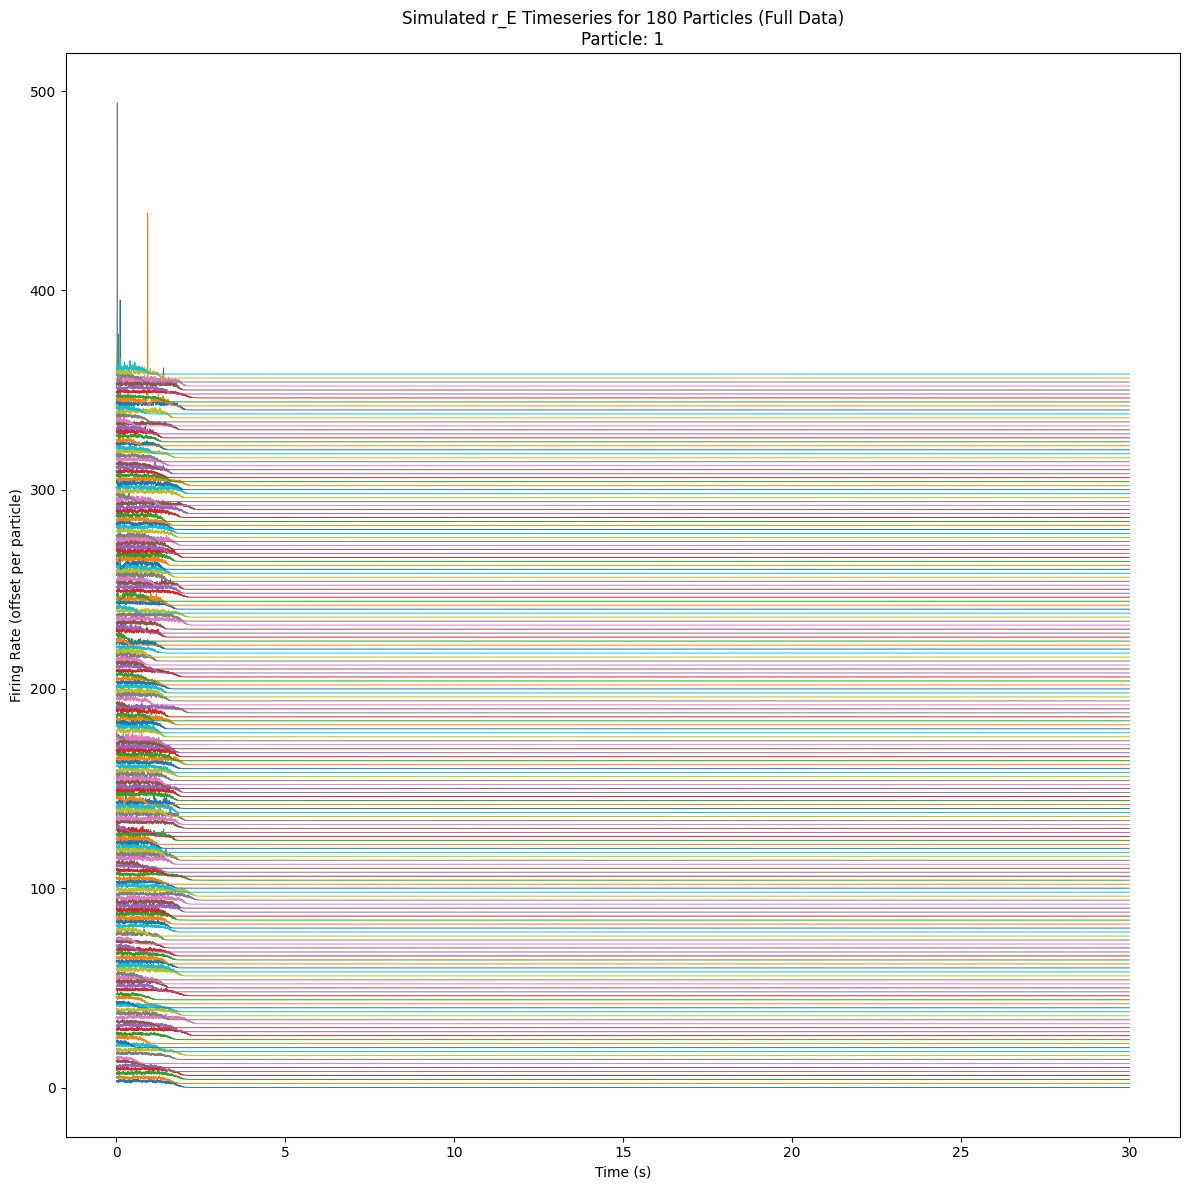

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the timeseries for all 180 regions using the full data (not the cut one)
plt.figure(figsize=(12, 12))  # Make the plot square
offset = 2.0  # vertical offset for clarity

for i in range(r_E_data.shape[0]):
    plt.plot(
        np.arange(r_E_data.shape[1]) * (dt * n_save),
        r_E_data[i] + i * offset,
        lw=0.7,
        # label=f"Particle {i+1}"  # label every particle/region
    )

plt.xlabel("Time (s)")
plt.ylabel("Firing Rate (offset per particle)")
plt.title(f"Simulated r_E Timeseries for 180 Particles (Full Data)\nParticle: {particle_idx}")
# Removed legend as per instructions
plt.gca().set_aspect('auto')  # Let axes scale, but figure is square
plt.tight_layout()
plt.show()


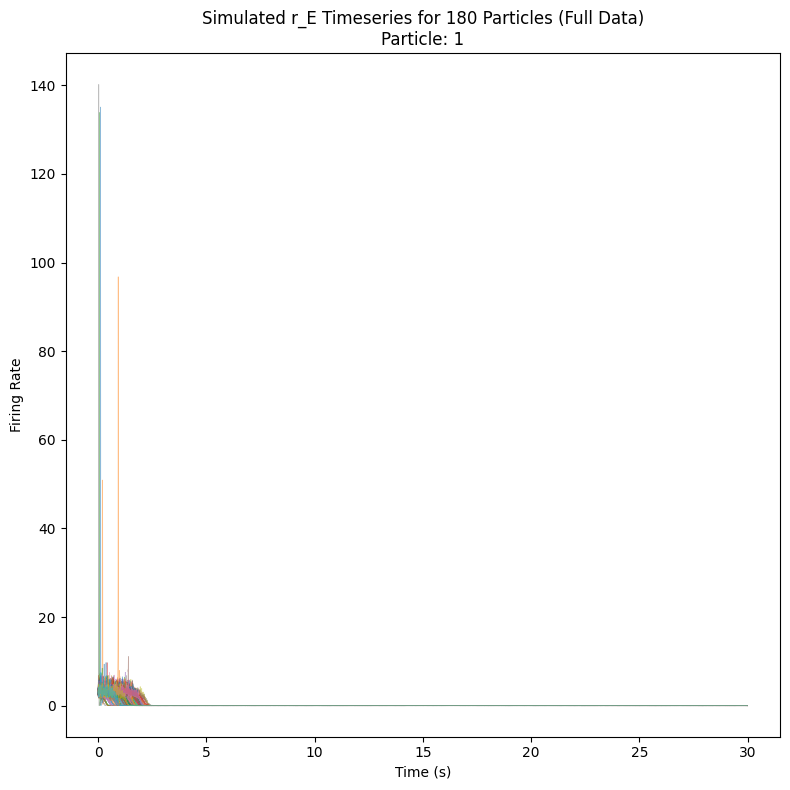

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the timeseries for all 180 regions without vertical offset (overlaid)
plt.figure(figsize=(8, 8))  # More square and compact
for i in range(r_E_data.shape[0]):
    plt.plot(
        np.arange(r_E_data.shape[1]) * (dt * n_save),
        r_E_data[i],
        lw=0.5,
        alpha=0.5
    )

plt.xlabel("Time (s)")
plt.ylabel("Firing Rate")
plt.title(f"Simulated r_E Timeseries for 180 Particles (Full Data)\nParticle: {particle_idx}")
plt.tight_layout()
plt.show()


In [8]:
# Numerical Simulations for Both Models
import numpy as np
from joblib import Parallel, delayed
import os
from hbnm.bnm import Bnm

# Simulation parameters
total_time = 15.0  # 15 seconds total
discard_time = 7.0  # discard first 7 seconds
dt = 0.0001
n_save = 10
n_particles = 10
n_iterations = 10

# Calculate time points for saved data (after discarding initial period)
save_time = total_time - discard_time  # 8 seconds of data to save
discard_points = int(discard_time / (dt * n_save))  # points to discard
n_timepoints_total = int(total_time / (dt * n_save)) + 1
n_timepoints_save = int(save_time / (dt * n_save)) + 1

print(f"Simulation setup:")
print(f"Total time: {total_time}s, Discard: {discard_time}s, Save: {save_time}s")
print(f"Total timepoints: {n_timepoints_total}, Discard: {discard_points}, Save: {n_timepoints_save}")

def run_homogeneous_simulation(particle_idx, iteration):
    """Run a single homogeneous simulation for one particle and iteration"""
    # Create homogeneous model for this particle
    model = Bnm(sc)
    model.set('w_EI', theta_homogeneous[0, particle_idx])
    model.set('w_EE', theta_homogeneous[1, particle_idx])
    model.set('G', theta_homogeneous[2, particle_idx])
    
    # Run simulation
    model.dmf.integrate(
        t=total_time,
        dt=dt,
        n_save=n_save,
        delays=False,
        include_BOLD=True,
        from_fixed=True
    )
    
    # Get r_E data and discard first part
    r_E_data = model.dmf.sim.time_series('r_E')
    r_E_data_cut = r_E_data[:, discard_points:]
    
    return {
        'particle': particle_idx,
        'iteration': iteration,
        'r_E': r_E_data_cut,
        'model_type': 'homogeneous'
    }

def run_heterogeneous_simulation(particle_idx, iteration):
    """Run a single heterogeneous simulation for one particle and iteration"""
    # Create heterogeneous model for this particle
    model = Bnm(sc, gradient=hmap)
    model.set('w_EI', (theta_heterogeneous[0, particle_idx], theta_heterogeneous[1, particle_idx]))
    model.set('w_EE', (theta_heterogeneous[2, particle_idx], theta_heterogeneous[3, particle_idx]))
    model.set('G', theta_heterogeneous[4, particle_idx])
    
    # Run simulation
    model.dmf.integrate(
        t=total_time,
        dt=dt,
        n_save=n_save,
        delays=False,
        include_BOLD=True,
        from_fixed=True
    )
    
    # Get r_E data and discard first part
    r_E_data = model.dmf.sim.time_series('r_E')
    r_E_data_cut = r_E_data[:, discard_points:]
    
    return {
        'particle': particle_idx,
        'iteration': iteration,
        'r_E': r_E_data_cut,
        'model_type': 'heterogeneous'
    }

print("Functions defined. Ready to run simulations...")


Simulation setup:
Total time: 15.0s, Discard: 7.0s, Save: 8.0s
Total timepoints: 15001, Discard: 7000, Save: 8001
Functions defined. Ready to run simulations...


In [9]:
# Run parallel simulations and save results

# Create lists of all simulation jobs
homogeneous_jobs = [(p, i) for p in range(n_particles) for i in range(n_iterations)]
heterogeneous_jobs = [(p, i) for p in range(n_particles) for i in range(n_iterations)]

print(f"Running {len(homogeneous_jobs)} homogeneous simulations...")
print(f"Running {len(heterogeneous_jobs)} heterogeneous simulations...")

# Run homogeneous simulations in parallel
print("\nStarting homogeneous simulations...")
homogeneous_results = Parallel(n_jobs=-1, verbose=1)(
    delayed(run_homogeneous_simulation)(particle_idx, iteration) 
    for particle_idx, iteration in homogeneous_jobs
)

print(f"\nCompleted {len(homogeneous_results)} homogeneous simulations")

# Run heterogeneous simulations in parallel
print("\nStarting heterogeneous simulations...")
heterogeneous_results = Parallel(n_jobs=-1, verbose=1)(
    delayed(run_heterogeneous_simulation)(particle_idx, iteration) 
    for particle_idx, iteration in heterogeneous_jobs
)

print(f"\nCompleted {len(heterogeneous_results)} heterogeneous simulations")

# Organize results into arrays
def organize_results(results):
    """Organize simulation results into structured arrays"""
    n_regions = results[0]['r_E'].shape[0]
    n_timepoints = results[0]['r_E'].shape[1]
    
    # Initialize arrays: [particle, iteration, region, time]
    data_array = np.zeros((n_particles, n_iterations, n_regions, n_timepoints))
    
    for result in results:
        p, i = result['particle'], result['iteration']
        data_array[p, i, :, :] = result['r_E']
    
    return data_array

print("\nOrganizing results...")
homogeneous_data = organize_results(homogeneous_results)
heterogeneous_data = organize_results(heterogeneous_results)

print(f"Homogeneous data shape: {homogeneous_data.shape}")
print(f"Heterogeneous data shape: {heterogeneous_data.shape}")

# Create output directory if it doesn't exist
output_path = "/home/frank/HBNM/experiments/INTs/INT_Outputs/"
os.makedirs(output_path, exist_ok=True)

# Save simulation metadata and results to NPZ files
simulation_metadata = {
    'total_time': total_time,
    'discard_time': discard_time,
    'save_time': save_time,
    'dt': dt,
    'n_save': n_save,
    'n_particles': n_particles,
    'n_iterations': n_iterations,
    'n_regions': homogeneous_data.shape[2],
    'n_timepoints_save': n_timepoints_save,
    'discard_points': discard_points
}

# Save homogeneous results
np.savez(
    os.path.join(output_path, 'homogeneous_simulations.npz'),
    data=homogeneous_data,
    **simulation_metadata
)

# Save heterogeneous results
np.savez(
    os.path.join(output_path, 'heterogeneous_simulations.npz'),
    data=heterogeneous_data,
    **simulation_metadata
)

print(f"\nSaved results to:")
print(f"- {os.path.join(output_path, 'homogeneous_simulations.npz')}")
print(f"- {os.path.join(output_path, 'heterogeneous_simulations.npz')}")
print(f"\nEach file contains:")
print(f"- 'data': Array with shape (particles={n_particles}, iterations={n_iterations}, regions={homogeneous_data.shape[2]}, timepoints={n_timepoints_save})")
print(f"- Simulation metadata (times, parameters, etc.)")
print(f"\nSimulations completed successfully!")


Running 100 homogeneous simulations...
Running 100 heterogeneous simulations...

Starting homogeneous simulations...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 96 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of 100 | elapsed:   26.9s remaining:  4.0min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   38.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 96 concurrent workers.



Completed 100 homogeneous simulations

Starting heterogeneous simulations...


[Parallel(n_jobs=-1)]: Done  10 out of 100 | elapsed:   25.5s remaining:  3.8min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   33.3s finished



Completed 100 heterogeneous simulations

Organizing results...
Homogeneous data shape: (10, 10, 180, 8001)
Heterogeneous data shape: (10, 10, 180, 8001)

Saved results to:
- /home/frank/HBNM/experiments/INTs/INT_Outputs/homogeneous_simulations.npz
- /home/frank/HBNM/experiments/INTs/INT_Outputs/heterogeneous_simulations.npz

Each file contains:
- 'data': Array with shape (particles=10, iterations=10, regions=180, timepoints=8001)
- Simulation metadata (times, parameters, etc.)

Simulations completed successfully!


# After Julia Computation

AI KEEP THIS INTACT

In [39]:
# Load the timescales results saved by Julia
import numpy as np
import pandas as pd

timescales_path = '/home/frank/HBNM/experiments/INTs/INT_Outputs/timescales_results.npz'
timescales_data = np.load(timescales_path, allow_pickle=True)

acw50_homogeneous = timescales_data['acw50_homogeneous']
tau_homogeneous = timescales_data['tau_homogeneous']
acw50_heterogeneous = timescales_data['acw50_heterogeneous']
tau_heterogeneous = timescales_data['tau_heterogeneous']
auc_homogeneous = timescales_data['auc_homogeneous']
auc_heterogeneous = timescales_data['auc_heterogeneous']

# Load the parcellation dataframe
parcellation_df_L = pd.read_csv('/home/frank/HBNM/data/parcellation_df_L.csv')
print(f"Loaded parcellation_df_L with shape: {parcellation_df_L.shape}")

# For each particle, add the acw50 and tau to the parcellation dataframe
for particle in range(acw50_homogeneous.shape[0]):
    parcellation_df_L[f'homogeneous_acw50_particle_{particle}'] = acw50_homogeneous[particle, :]
    parcellation_df_L[f'homogeneous_tau_particle_{particle}'] = tau_homogeneous[particle, :]
    parcellation_df_L[f'heterogeneous_acw50_particle_{particle}'] = acw50_heterogeneous[particle, :]
    parcellation_df_L[f'heterogeneous_tau_particle_{particle}'] = tau_heterogeneous[particle, :]
    parcellation_df_L[f'homogeneous_auc_particle_{particle}'] = auc_homogeneous[particle, :]
    parcellation_df_L[f'heterogeneous_auc_particle_{particle}'] = auc_heterogeneous[particle, :]

print("parcellation_df_L shape after adding timescales:", parcellation_df_L.shape)

Loaded parcellation_df_L with shape: (180, 10)
parcellation_df_L shape after adding timescales: (180, 70)


In [40]:
parcellation_df_L

,Parcel,Hemisphere,AreaAbbreviation,AreaName,SectionNumber,Region,NetworkID,NetworkName,NetworkRGB,NetworkRGBA,...,heterogeneous_acw50_particle_8,heterogeneous_tau_particle_8,homogeneous_auc_particle_8,heterogeneous_auc_particle_8,homogeneous_acw50_particle_9,homogeneous_tau_particle_9,heterogeneous_acw50_particle_9,heterogeneous_tau_particle_9,homogeneous_auc_particle_9,heterogeneous_auc_particle_9
0,1,L,V1,Primary Visual Cortex,1,Primary_Visual,1,Visual1,"[0, 0, 255]","[0, 0, 255, 255]",...,0.019,0.058517,0.003034,0.059556,0.004,0.003375,0.015,0.053005,0.003428,0.061811
1,2,L,MST,Medial Superior\nTemporal Area,5,MT+_Complex_and_Neighboring_Visual_Areas,2,Visual2,"[100, 0, 255]","[100, 0, 255, 255]",...,0.016,0.053051,0.002936,0.057327,0.004,0.003760,0.014,0.043035,0.003367,0.044459
2,3,L,V6,Sixth Visual Area,3,Dorsal_Stream_Visual,2,Visual2,"[100, 0, 255]","[100, 0, 255, 255]",...,0.017,0.049908,0.002933,0.052455,0.004,0.004662,0.016,0.055702,0.003685,0.054385
3,4,L,V2,Second Visual Area,2,Early_Visual,2,Visual2,"[100, 0, 255]","[100, 0, 255, 255]",...,0.018,0.055045,0.003006,0.058531,0.004,0.004019,0.014,0.045105,0.003655,0.051520
4,5,L,V3,Third Visual Area,2,Early_Visual,2,Visual2,"[100, 0, 255]","[100, 0, 255, 255]",...,0.018,0.053376,0.003036,0.056725,0.004,0.004091,0.013,0.041946,0.003647,0.046617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,176,L,STSva,Area STSv anterior,11,Auditory_Association,9,Default,"[255, 0, 0]","[255, 0, 0, 255]",...,0.008,0.021691,0.002949,0.029426,0.004,0.005675,0.008,0.022272,0.003869,0.031835
176,177,L,TE1m,Area TE1 Middle,14,Lateral_Temporal,9,Default,"[255, 0, 0]","[255, 0, 0, 255]",...,0.007,0.016493,0.003003,0.020565,0.004,0.003396,0.008,0.020575,0.003363,0.027937
177,178,L,PI,Para-Insular Area,12,Insular_and_Frontal_Opercular,4,Cingulo-Opercular,"[153, 0, 153]","[153, 0, 153, 255]",...,0.007,0.016102,0.002979,0.018965,0.004,0.003362,0.008,0.019578,0.003382,0.021080
178,179,L,a32pr,Area anterior 32\nprime,19,Anterior_Cingulate_and_Medial_Prefrontal,4,Cingulo-Opercular,"[153, 0, 153]","[153, 0, 153, 255]",...,0.008,0.017939,0.002930,0.028683,0.004,0.003785,0.007,0.018433,0.003382,0.026638


In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_network_timescales(df, model_type, particle_num):
    """
    Plot timescales per network for a specific model and particle.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The parcellation dataframe with timescale columns
    model_type : str
        Either 'homogeneous' or 'heterogeneous'
    particle_num : int
        The particle number to analyze
        
    Returns:
    --------
    tuple: (ordered_timescales_df, fig)
        - ordered_timescales_df: DataFrame with networks ordered by mean ACW50
        - fig: matplotlib figure object
    """
    
    # Validate inputs
    if model_type not in ['homogeneous', 'heterogeneous']:
        raise ValueError("model_type must be 'homogeneous' or 'heterogeneous'")
    
    # Get the column names for this model and particle
    acw50_col = f'{model_type}_acw50_particle_{particle_num}'
    tau_col = f'{model_type}_tau_particle_{particle_num}'
    auc_col = f'{model_type}_auc_particle_{particle_num}'

    # Check if columns exist
    if acw50_col not in df.columns or tau_col not in df.columns or auc_col not in df.columns:
        available_cols = [col for col in df.columns if f'{model_type}_' in col and f'particle_{particle_num}' in col]
        raise ValueError(f"Columns not found. Available columns for {model_type} particle {particle_num}: {available_cols}")
    
    # Create a subset dataframe with the relevant columns
    plot_df = df[['NetworkName', acw50_col, tau_col, auc_col]].copy()
    plot_df.columns = ['NetworkName', 'ACW50', 'Tau', 'AUC']
    
    # Compute network averages and order by ACW50
    network_averages = plot_df.groupby('NetworkName')[['ACW50', 'Tau', 'AUC']].mean().reset_index()
    ordered_timescales = network_averages.sort_values('Tau', ascending=True)
    
    # Create the box plot
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 8))
    
    # Prepare data for box plot
    networks = ordered_timescales['NetworkName'].tolist()
    acw50_data = [plot_df[plot_df['NetworkName'] == net]['ACW50'].values for net in networks]
    tau_data = [plot_df[plot_df['NetworkName'] == net]['Tau'].values for net in networks]
    auc_data = [plot_df[plot_df['NetworkName'] == net]['AUC'].values for net in networks]
    
    # Create box plots
    bp1 = ax1.boxplot(acw50_data, tick_labels=networks, patch_artist=True)
    bp2 = ax2.boxplot(tau_data, tick_labels=networks, patch_artist=True)
    bp3 = ax3.boxplot(auc_data, tick_labels=networks, patch_artist=True)
    
    # Customize ACW50 plot
    ax1.set_title(f'{model_type.title()} Model - ACW50 Timescales (Particle {particle_num})', fontsize=14, fontweight='bold')
    ax1.set_ylabel('ACW50 (seconds)', fontsize=12)
    ax1.set_xlabel('Network', fontsize=12)
    ax1.tick_params(axis='x', rotation=45, labelsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Customize Tau plot
    ax2.set_title(f'{model_type.title()} Model - Tau Timescales (Particle {particle_num})', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Tau (seconds)', fontsize=12)
    ax2.set_xlabel('Network', fontsize=12)      
    ax2.tick_params(axis='x', rotation=45, labelsize=8)
    ax2.grid(True, alpha=0.3)
    
    # Customize AUC plot
    ax3.set_title(f'{model_type.title()} Model - AUC Timescales (Particle {particle_num})', fontsize=14, fontweight='bold')
    ax3.set_ylabel('AUC', fontsize=12)
    ax3.set_xlabel('Network', fontsize=12)
    ax3.tick_params(axis='x', rotation=45, labelsize=8)
    ax3.grid(True, alpha=0.3)
    
    # Color the boxes
    colors = plt.cm.Set3(np.linspace(0, 1, len(networks)))
    for patch, color in zip(bp1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for patch, color in zip(bp2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for patch, color in zip(bp3['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)    
    
    plt.tight_layout()
    
    # Print ordered timescales
    print(f"\n{model_type.title()} Model - Particle {particle_num}")
    print("=" * 60)
    print("Networks ordered by mean ACW50 (ascending):")
    print("-" * 60)
    for idx, row in ordered_timescales.iterrows():
        print(f"{row['NetworkName']:<25} ACW50: {row['ACW50']:.4f}s  Tau: {row['Tau']:.4f}s  AUC: {row['AUC']:.4f}")
    
    return ordered_timescales, fig

Testing with Heterogeneous Model, Particle 0:

Heterogeneous Model - Particle 0
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Cingulo-Opercular         ACW50: 0.0076s  Tau: 0.0188s  AUC: 0.0228
Ventral-Multimodal        ACW50: 0.0075s  Tau: 0.0188s  AUC: 0.0204
Default                   ACW50: 0.0078s  Tau: 0.0202s  AUC: 0.0244
Dorsal-attention          ACW50: 0.0079s  Tau: 0.0202s  AUC: 0.0251
Frontoparietal            ACW50: 0.0079s  Tau: 0.0208s  AUC: 0.0249
Language                  ACW50: 0.0079s  Tau: 0.0210s  AUC: 0.0250
Posterior-Multimodal      ACW50: 0.0080s  Tau: 0.0215s  AUC: 0.0249
Orbito-Affective          ACW50: 0.0087s  Tau: 0.0253s  AUC: 0.0265
Somatomotor               ACW50: 0.0093s  Tau: 0.0269s  AUC: 0.0307
Visual2                   ACW50: 0.0104s  Tau: 0.0312s  AUC: 0.0360
Visual1                   ACW50: 0.0100s  Tau: 0.0313s  AUC: 0.0367
Auditory                  ACW50: 0.0106s  Tau: 0.0322s  AUC: 0.0365

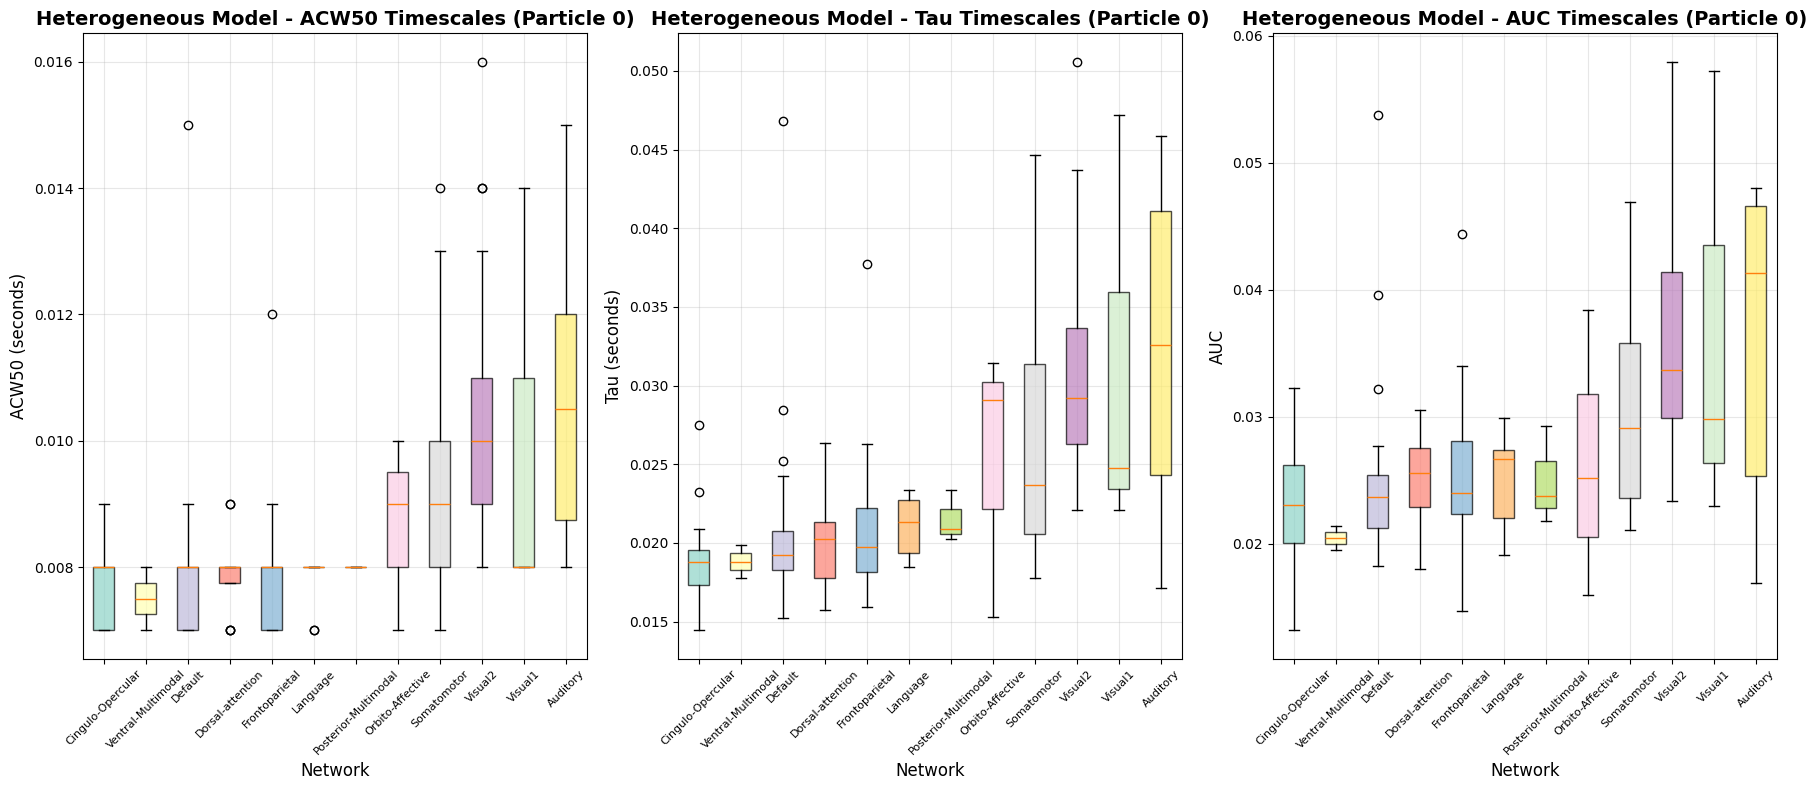



Testing with Heterogeneous Model, Particle 1:

Heterogeneous Model - Particle 1
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Cingulo-Opercular         ACW50: 0.0071s  Tau: 0.0170s  AUC: 0.0220
Dorsal-attention          ACW50: 0.0072s  Tau: 0.0172s  AUC: 0.0214
Language                  ACW50: 0.0073s  Tau: 0.0173s  AUC: 0.0219
Ventral-Multimodal        ACW50: 0.0070s  Tau: 0.0176s  AUC: 0.0201
Default                   ACW50: 0.0073s  Tau: 0.0181s  AUC: 0.0228
Frontoparietal            ACW50: 0.0074s  Tau: 0.0183s  AUC: 0.0232
Posterior-Multimodal      ACW50: 0.0073s  Tau: 0.0188s  AUC: 0.0265
Somatomotor               ACW50: 0.0079s  Tau: 0.0204s  AUC: 0.0256
Orbito-Affective          ACW50: 0.0077s  Tau: 0.0204s  AUC: 0.0250
Visual1                   ACW50: 0.0080s  Tau: 0.0216s  AUC: 0.0284
Visual2                   ACW50: 0.0080s  Tau: 0.0217s  AUC: 0.0271
Auditory                  ACW50: 0.0085s  Tau: 0.0235s  AUC: 0.02

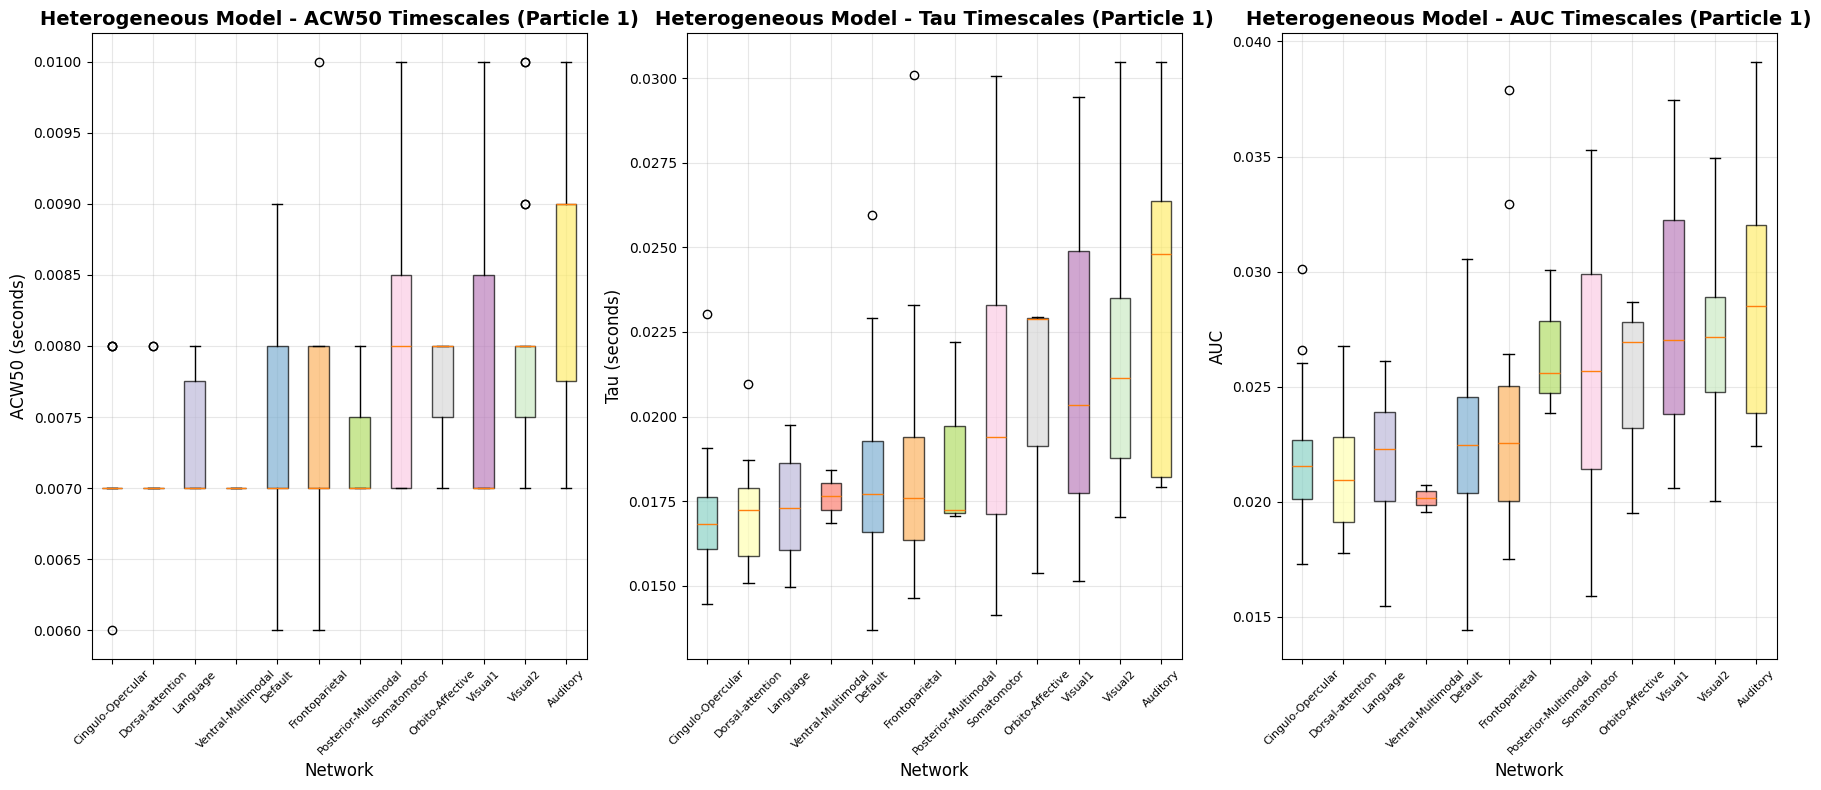



Testing with Heterogeneous Model, Particle 2:

Heterogeneous Model - Particle 2
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Posterior-Multimodal      ACW50: 0.0073s  Tau: 0.0162s  AUC: 0.0207
Cingulo-Opercular         ACW50: 0.0071s  Tau: 0.0167s  AUC: 0.0213
Dorsal-attention          ACW50: 0.0072s  Tau: 0.0168s  AUC: 0.0215
Ventral-Multimodal        ACW50: 0.0070s  Tau: 0.0170s  AUC: 0.0206
Frontoparietal            ACW50: 0.0072s  Tau: 0.0172s  AUC: 0.0218
Orbito-Affective          ACW50: 0.0073s  Tau: 0.0172s  AUC: 0.0209
Default                   ACW50: 0.0072s  Tau: 0.0173s  AUC: 0.0220
Language                  ACW50: 0.0072s  Tau: 0.0179s  AUC: 0.0230
Somatomotor               ACW50: 0.0076s  Tau: 0.0183s  AUC: 0.0232
Visual1                   ACW50: 0.0073s  Tau: 0.0184s  AUC: 0.0235
Visual2                   ACW50: 0.0076s  Tau: 0.0191s  AUC: 0.0245
Auditory                  ACW50: 0.0076s  Tau: 0.0199s  AUC: 0.02

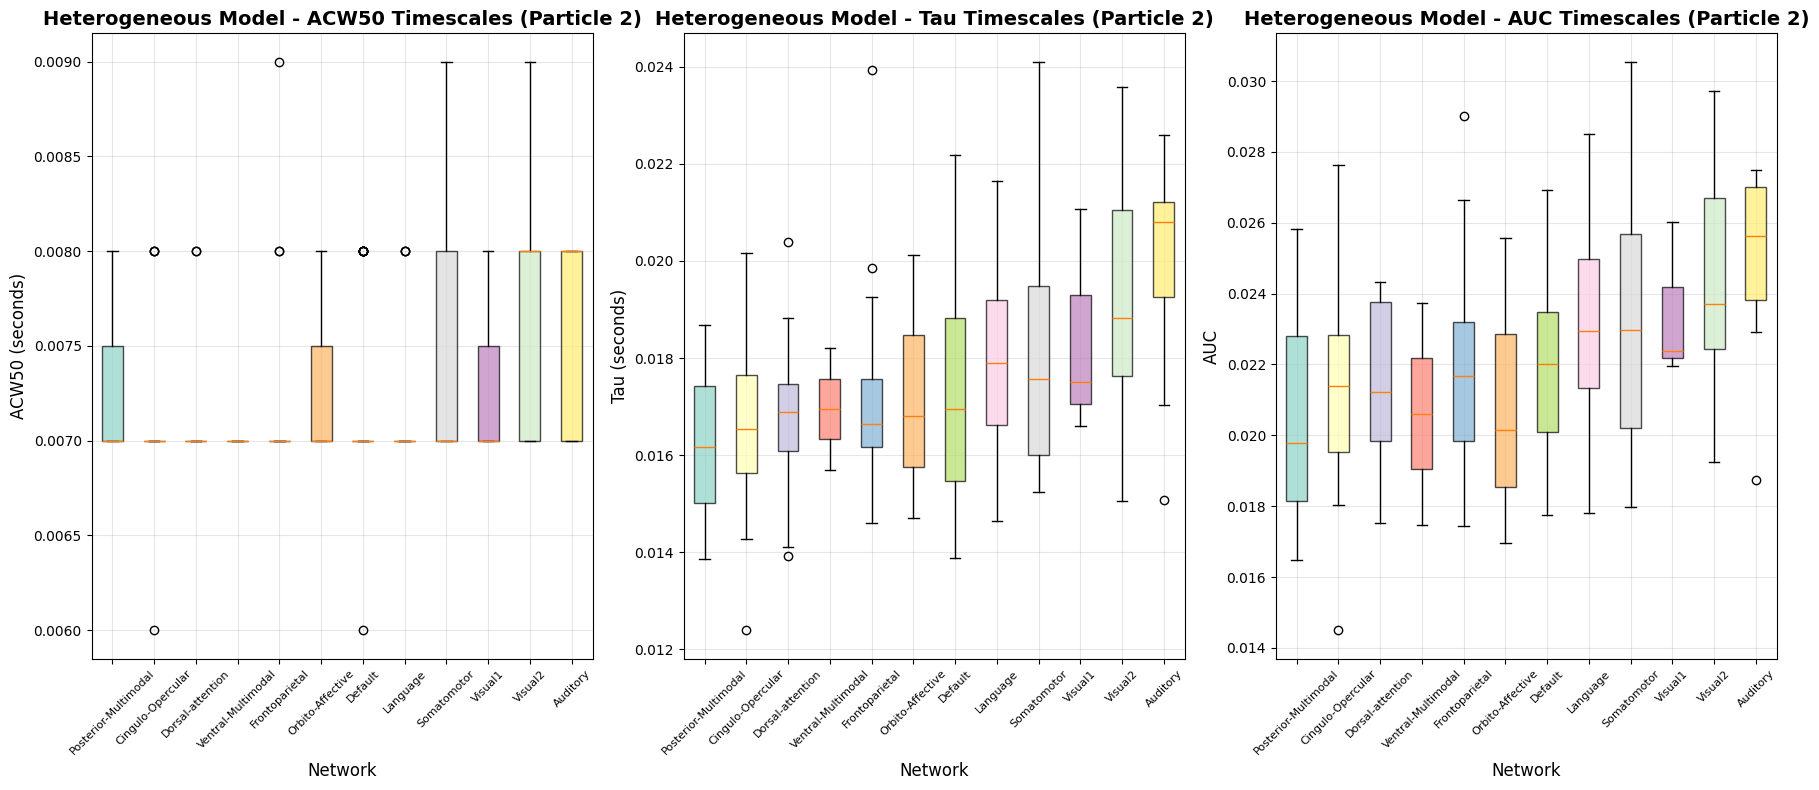



Testing with Heterogeneous Model, Particle 3:

Heterogeneous Model - Particle 3
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Ventral-Multimodal        ACW50: 0.0070s  Tau: 0.0152s  AUC: 0.0185
Cingulo-Opercular         ACW50: 0.0070s  Tau: 0.0164s  AUC: 0.0211
Posterior-Multimodal      ACW50: 0.0070s  Tau: 0.0168s  AUC: 0.0219
Language                  ACW50: 0.0070s  Tau: 0.0174s  AUC: 0.0224
Dorsal-attention          ACW50: 0.0071s  Tau: 0.0174s  AUC: 0.0221
Frontoparietal            ACW50: 0.0073s  Tau: 0.0177s  AUC: 0.0224
Default                   ACW50: 0.0073s  Tau: 0.0179s  AUC: 0.0230
Somatomotor               ACW50: 0.0075s  Tau: 0.0188s  AUC: 0.0238
Visual1                   ACW50: 0.0077s  Tau: 0.0200s  AUC: 0.0257
Orbito-Affective          ACW50: 0.0083s  Tau: 0.0206s  AUC: 0.0254
Visual2                   ACW50: 0.0079s  Tau: 0.0209s  AUC: 0.0260
Auditory                  ACW50: 0.0088s  Tau: 0.0245s  AUC: 0.03

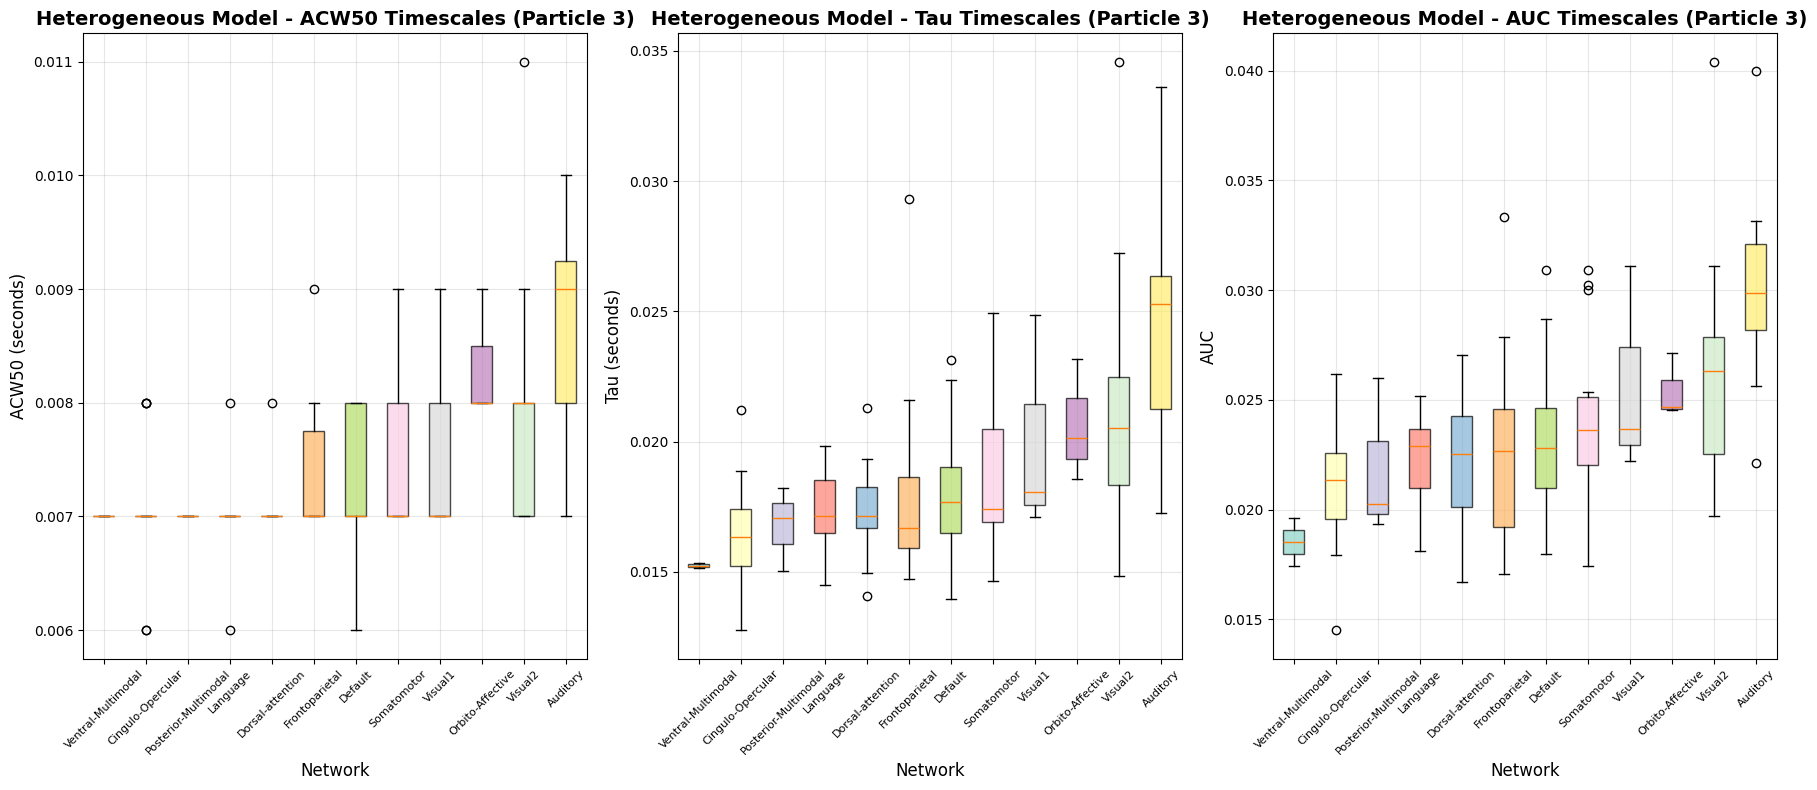



Testing with Heterogeneous Model, Particle 4:

Heterogeneous Model - Particle 4
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Ventral-Multimodal        ACW50: 0.0070s  Tau: 0.0165s  AUC: 0.0221
Cingulo-Opercular         ACW50: 0.0072s  Tau: 0.0174s  AUC: 0.0220
Default                   ACW50: 0.0072s  Tau: 0.0175s  AUC: 0.0222
Frontoparietal            ACW50: 0.0072s  Tau: 0.0177s  AUC: 0.0221
Posterior-Multimodal      ACW50: 0.0073s  Tau: 0.0178s  AUC: 0.0227
Dorsal-attention          ACW50: 0.0073s  Tau: 0.0181s  AUC: 0.0227
Language                  ACW50: 0.0074s  Tau: 0.0185s  AUC: 0.0232
Somatomotor               ACW50: 0.0076s  Tau: 0.0195s  AUC: 0.0243
Visual2                   ACW50: 0.0078s  Tau: 0.0200s  AUC: 0.0247
Visual1                   ACW50: 0.0080s  Tau: 0.0208s  AUC: 0.0258
Auditory                  ACW50: 0.0079s  Tau: 0.0215s  AUC: 0.0264
Orbito-Affective          ACW50: 0.0077s  Tau: 0.0215s  AUC: 0.02

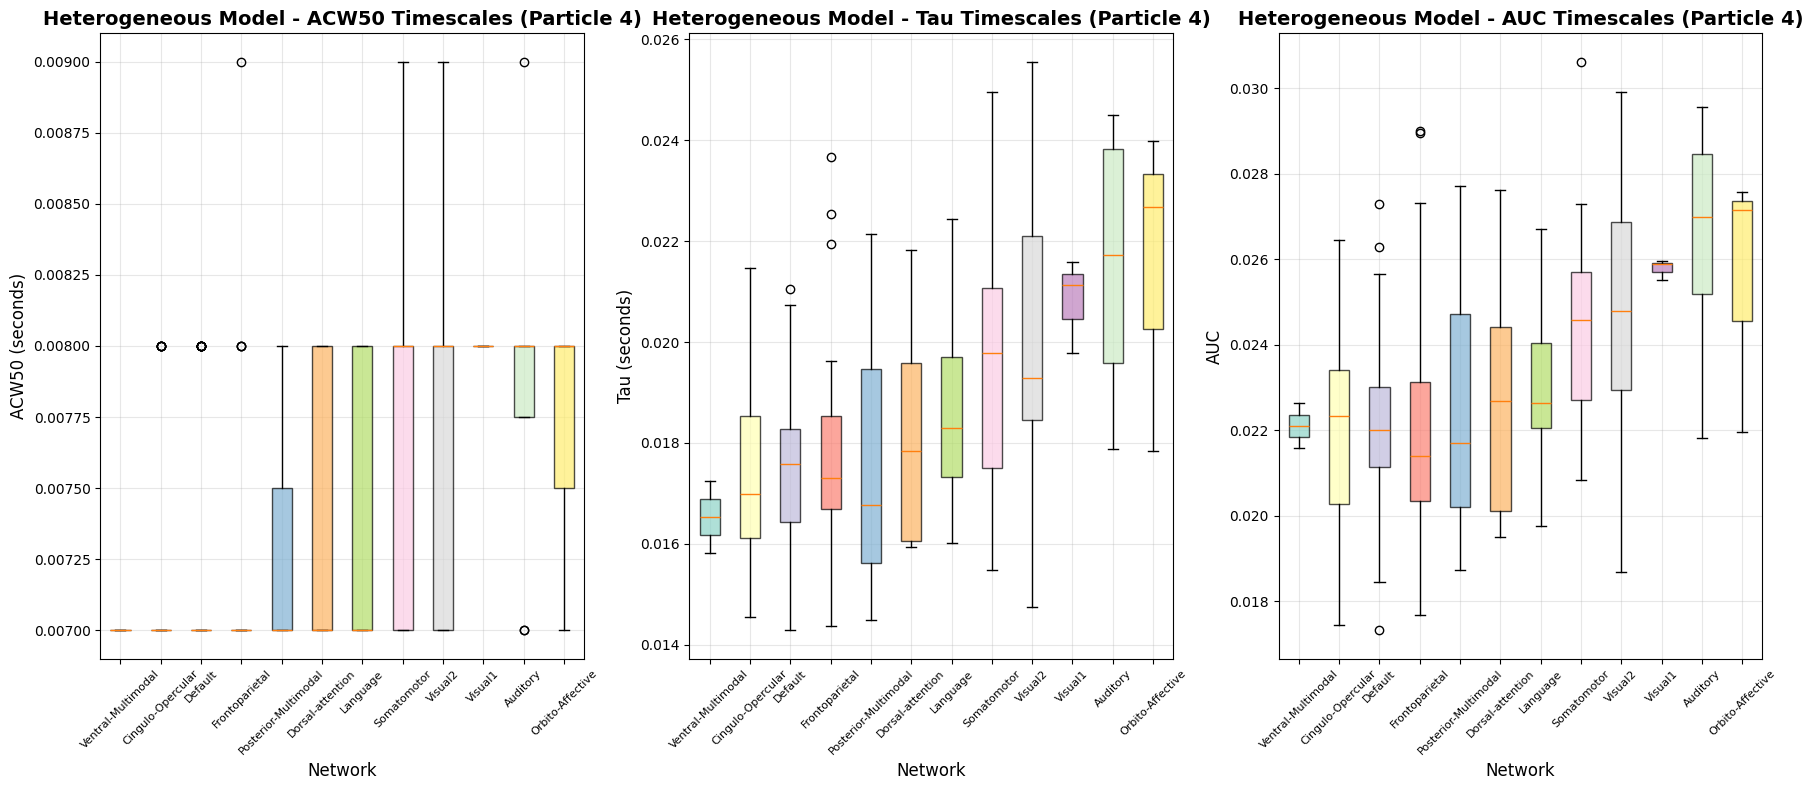



Testing with Heterogeneous Model, Particle 5:

Heterogeneous Model - Particle 5
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Cingulo-Opercular         ACW50: 0.0070s  Tau: 0.0166s  AUC: 0.0206
Language                  ACW50: 0.0071s  Tau: 0.0170s  AUC: 0.0209
Dorsal-attention          ACW50: 0.0072s  Tau: 0.0173s  AUC: 0.0210
Default                   ACW50: 0.0073s  Tau: 0.0175s  AUC: 0.0218
Frontoparietal            ACW50: 0.0073s  Tau: 0.0175s  AUC: 0.0218
Orbito-Affective          ACW50: 0.0073s  Tau: 0.0178s  AUC: 0.0235
Ventral-Multimodal        ACW50: 0.0070s  Tau: 0.0178s  AUC: 0.0236
Posterior-Multimodal      ACW50: 0.0077s  Tau: 0.0189s  AUC: 0.0248
Somatomotor               ACW50: 0.0076s  Tau: 0.0197s  AUC: 0.0251
Visual2                   ACW50: 0.0076s  Tau: 0.0197s  AUC: 0.0249
Auditory                  ACW50: 0.0081s  Tau: 0.0214s  AUC: 0.0262
Visual1                   ACW50: 0.0080s  Tau: 0.0216s  AUC: 0.02

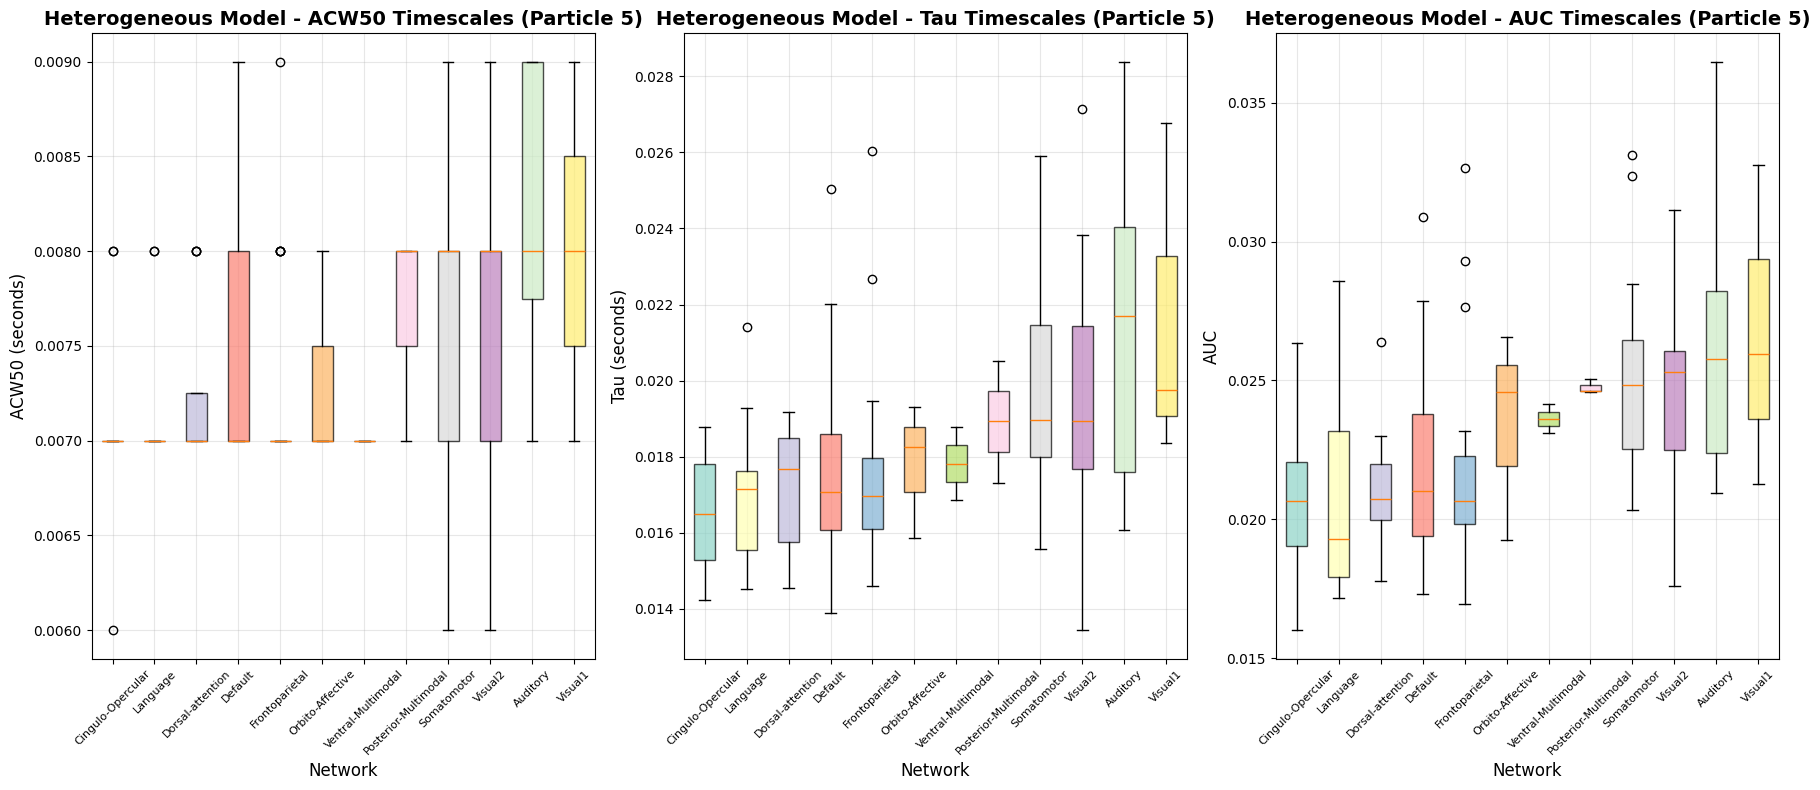



Testing with Heterogeneous Model, Particle 6:

Heterogeneous Model - Particle 6
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Ventral-Multimodal        ACW50: 0.0075s  Tau: 0.0177s  AUC: 0.0217
Cingulo-Opercular         ACW50: 0.0073s  Tau: 0.0178s  AUC: 0.0222
Dorsal-attention          ACW50: 0.0073s  Tau: 0.0183s  AUC: 0.0236
Language                  ACW50: 0.0074s  Tau: 0.0185s  AUC: 0.0232
Default                   ACW50: 0.0075s  Tau: 0.0187s  AUC: 0.0236
Posterior-Multimodal      ACW50: 0.0077s  Tau: 0.0194s  AUC: 0.0232
Frontoparietal            ACW50: 0.0080s  Tau: 0.0200s  AUC: 0.0249
Orbito-Affective          ACW50: 0.0083s  Tau: 0.0231s  AUC: 0.0286
Somatomotor               ACW50: 0.0086s  Tau: 0.0240s  AUC: 0.0297
Visual1                   ACW50: 0.0090s  Tau: 0.0255s  AUC: 0.0309
Visual2                   ACW50: 0.0090s  Tau: 0.0257s  AUC: 0.0315
Auditory                  ACW50: 0.0103s  Tau: 0.0315s  AUC: 0.03

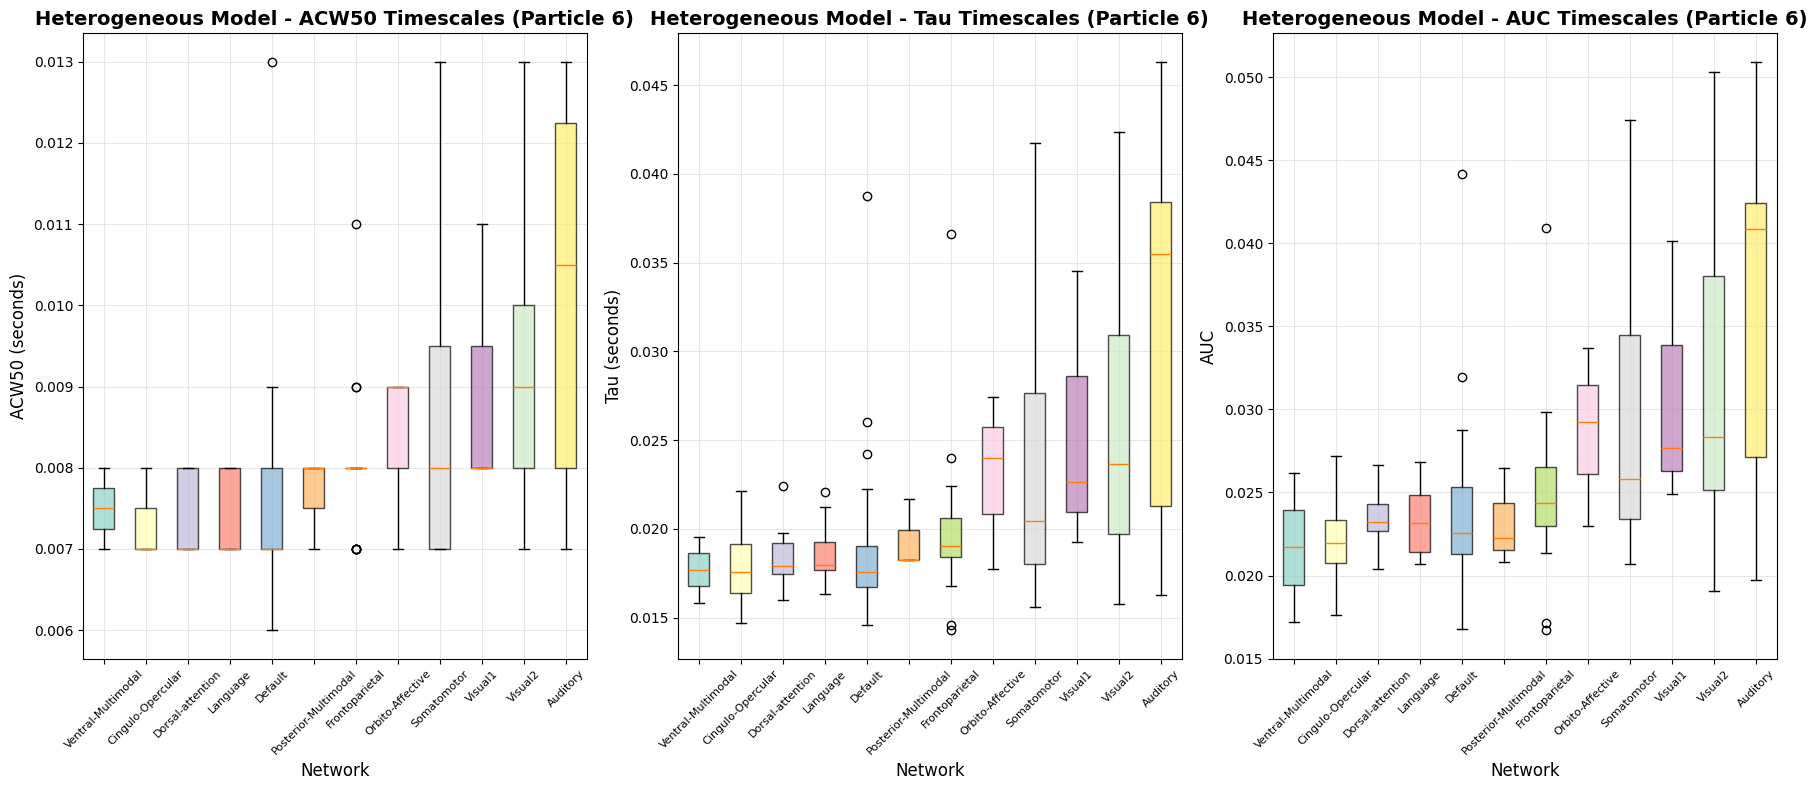



Testing with Heterogeneous Model, Particle 7:

Heterogeneous Model - Particle 7
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Ventral-Multimodal        ACW50: 0.0070s  Tau: 0.0153s  AUC: 0.0194
Cingulo-Opercular         ACW50: 0.0072s  Tau: 0.0172s  AUC: 0.0217
Dorsal-attention          ACW50: 0.0072s  Tau: 0.0176s  AUC: 0.0229
Language                  ACW50: 0.0074s  Tau: 0.0177s  AUC: 0.0230
Default                   ACW50: 0.0073s  Tau: 0.0178s  AUC: 0.0225
Frontoparietal            ACW50: 0.0073s  Tau: 0.0179s  AUC: 0.0226
Posterior-Multimodal      ACW50: 0.0073s  Tau: 0.0183s  AUC: 0.0239
Somatomotor               ACW50: 0.0075s  Tau: 0.0191s  AUC: 0.0243
Orbito-Affective          ACW50: 0.0073s  Tau: 0.0192s  AUC: 0.0226
Visual2                   ACW50: 0.0077s  Tau: 0.0198s  AUC: 0.0248
Visual1                   ACW50: 0.0083s  Tau: 0.0213s  AUC: 0.0266
Auditory                  ACW50: 0.0083s  Tau: 0.0225s  AUC: 0.02

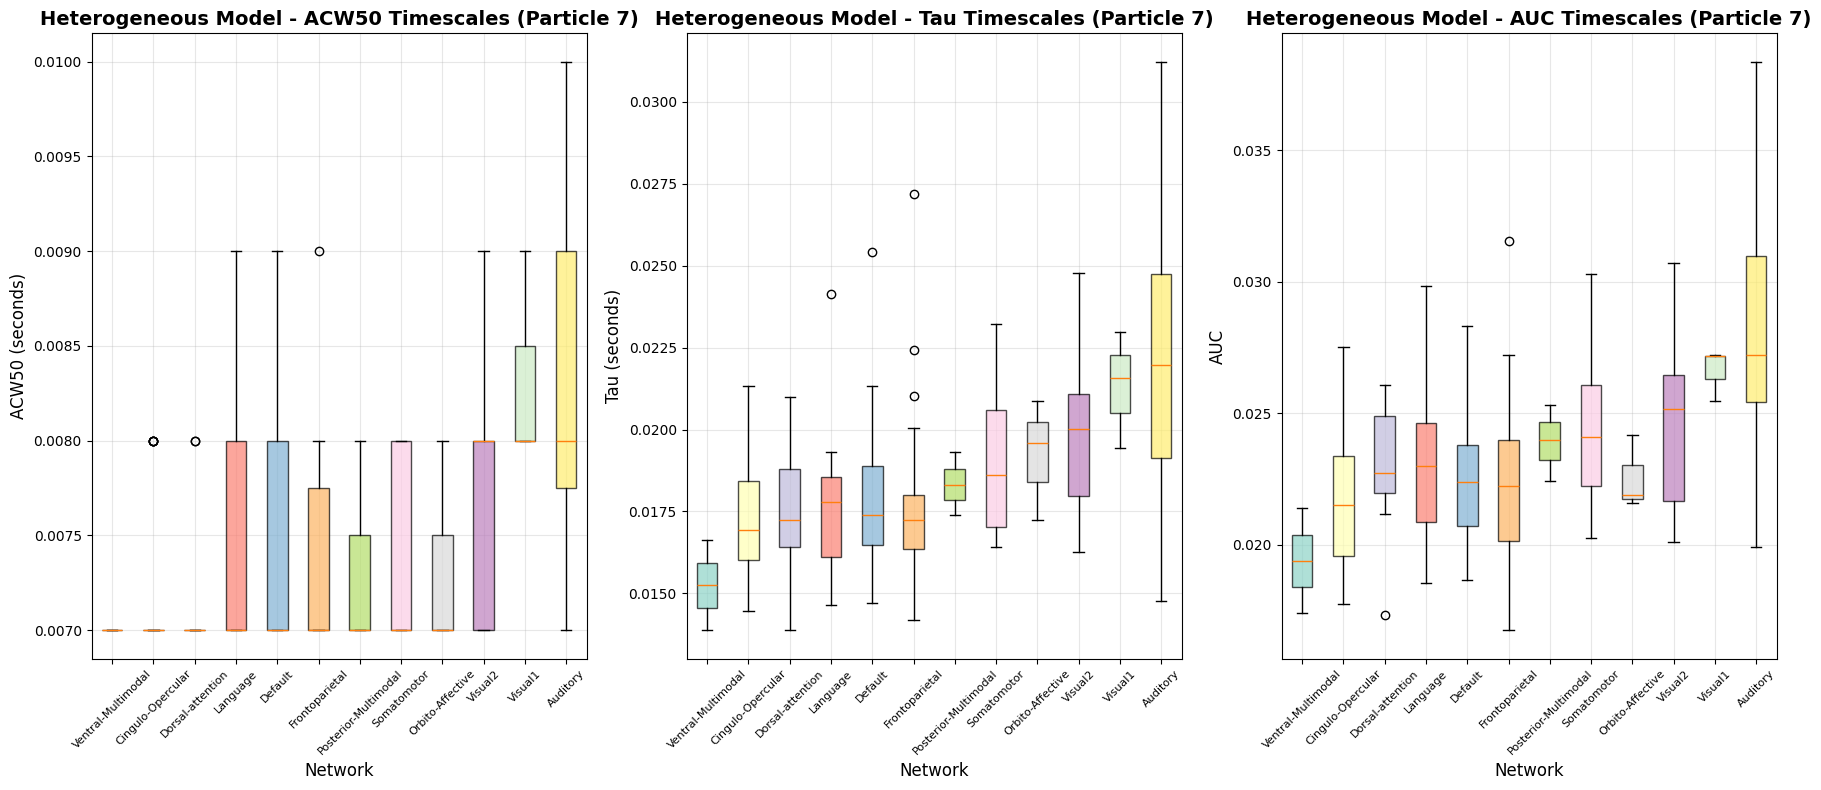



Testing with Heterogeneous Model, Particle 8:

Heterogeneous Model - Particle 8
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Ventral-Multimodal        ACW50: 0.0070s  Tau: 0.0176s  AUC: 0.0247
Cingulo-Opercular         ACW50: 0.0075s  Tau: 0.0187s  AUC: 0.0241
Language                  ACW50: 0.0079s  Tau: 0.0212s  AUC: 0.0266
Default                   ACW50: 0.0082s  Tau: 0.0213s  AUC: 0.0255
Frontoparietal            ACW50: 0.0087s  Tau: 0.0232s  AUC: 0.0271
Dorsal-attention          ACW50: 0.0085s  Tau: 0.0232s  AUC: 0.0280
Posterior-Multimodal      ACW50: 0.0087s  Tau: 0.0251s  AUC: 0.0322
Orbito-Affective          ACW50: 0.0103s  Tau: 0.0308s  AUC: 0.0336
Somatomotor               ACW50: 0.0119s  Tau: 0.0346s  AUC: 0.0393
Visual2                   ACW50: 0.0124s  Tau: 0.0375s  AUC: 0.0419
Visual1                   ACW50: 0.0123s  Tau: 0.0378s  AUC: 0.0422
Auditory                  ACW50: 0.0149s  Tau: 0.0452s  AUC: 0.04

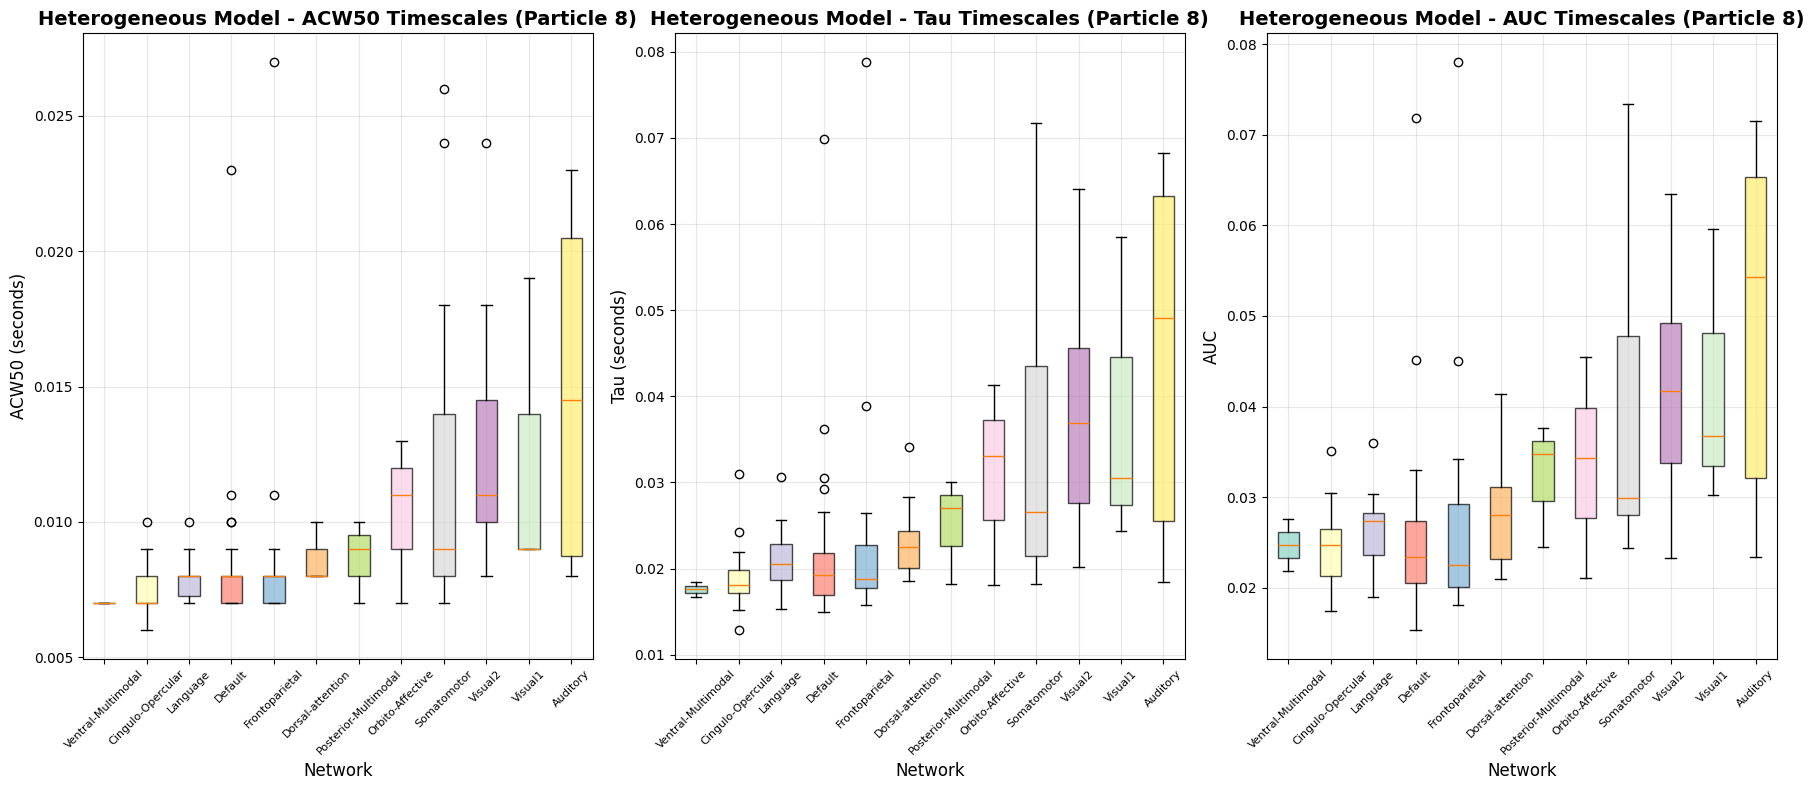



Testing with Heterogeneous Model, Particle 9:

Heterogeneous Model - Particle 9
Networks ordered by mean ACW50 (ascending):
------------------------------------------------------------
Ventral-Multimodal        ACW50: 0.0080s  Tau: 0.0192s  AUC: 0.0241
Cingulo-Opercular         ACW50: 0.0076s  Tau: 0.0201s  AUC: 0.0242
Default                   ACW50: 0.0083s  Tau: 0.0220s  AUC: 0.0268
Frontoparietal            ACW50: 0.0084s  Tau: 0.0227s  AUC: 0.0267
Language                  ACW50: 0.0084s  Tau: 0.0230s  AUC: 0.0275
Dorsal-attention          ACW50: 0.0085s  Tau: 0.0238s  AUC: 0.0280
Posterior-Multimodal      ACW50: 0.0090s  Tau: 0.0265s  AUC: 0.0330
Orbito-Affective          ACW50: 0.0090s  Tau: 0.0270s  AUC: 0.0315
Somatomotor               ACW50: 0.0110s  Tau: 0.0327s  AUC: 0.0382
Visual1                   ACW50: 0.0110s  Tau: 0.0345s  AUC: 0.0408
Visual2                   ACW50: 0.0115s  Tau: 0.0357s  AUC: 0.0403
Auditory                  ACW50: 0.0124s  Tau: 0.0377s  AUC: 0.04

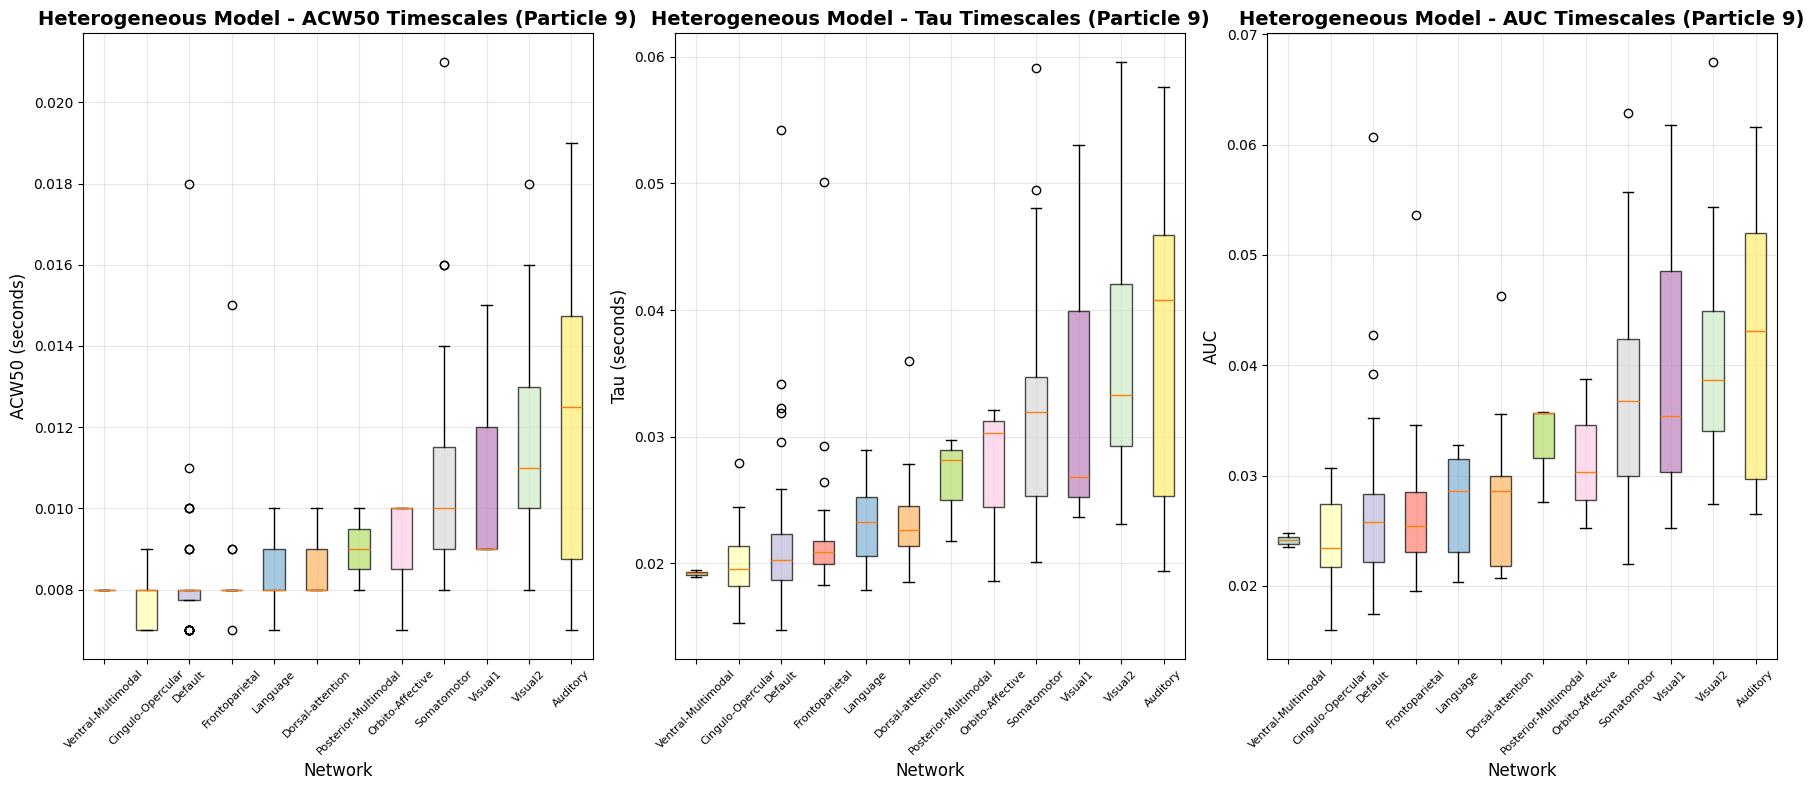

In [60]:
# Run the function on all heterogeneous models for all particles 0 to 9

ordered_hetero_all = []
figs_hetero_all = []

for particle_num in range(10):
    print(f"Testing with Heterogeneous Model, Particle {particle_num}:")
    ordered_hetero, fig_hetero = plot_network_timescales(parcellation_df_L, 'heterogeneous', particle_num)
    ordered_hetero_all.append(ordered_hetero)
    figs_hetero_all.append(fig_hetero)
    plt.show()
    print("\n" + "="*80 + "\n")

In [ ]:


# Load the parcellation dataframe
parcellation_df_L = pd.read_csv('/home/frank/HBNM/data/parcellation_df_L.csv')
print(f"Loaded parcellation_df_L with shape: {parcellation_df_L.shape}")

# Load the timescales results saved by Julia
timescales_path = '/home/frank/HBNM/experiments/INTs/INT_Outputs/timescales_results.npz'
timescales_data = np.load(timescales_path, allow_pickle=True)

# Extract arrays
acw50 = timescales_data['acw50']
tau = timescales_data['tau']
n_regions = int(timescales_data['n_regions'])
sampling_rate = float(timescales_data['sampling_rate'])
n_timepoints = int(timescales_data['n_timepoints'])

print(f"Loaded timescales results from {timescales_path}")
print(f"acw50 shape: {acw50.shape}, tau shape: {tau.shape}")
print(f"n_regions: {n_regions}, sampling_rate: {sampling_rate}, n_timepoints: {n_timepoints}")

# --- Match timescale with parcellation region ---
# Assume parcellation_df_L has at least 'region' and 'network' columns, and is ordered to match timescale arrays
# If not, you may need to sort or align indices accordingly

# Add timescale columns to the parcellation dataframe
parcellation_df_L['acw50'] = acw50
parcellation_df_L['tau'] = tau

# --- Print timescale for each network and order network by timescale (ascending) ---
# Group by NetworkName and compute mean timescales
network_timescales = parcellation_df_L.groupby('NetworkName')[['acw50', 'tau']].mean().reset_index()

# Order networks by mean acw50 timescale (ascending)
network_timescales_sorted = network_timescales.sort_values(by='acw50', ascending=True)

print("\nMean timescales for each network (ordered by acw50):")
for idx, row in network_timescales_sorted.iterrows():
    print(f"Network: {row['NetworkName']:<20}  Mean ACW50: {row['acw50']:.4f} s  Mean Tau: {row['tau']:.4f} s")


Loaded parcellation_df_L with shape: (180, 10)
Loaded timescales results from /home/frank/HBNM/experiments/INTs/INT_Outputs/timescales_results.npz
acw50 shape: (180,), tau shape: (180,)
n_regions: 180, sampling_rate: 1000.0, n_timepoints: 20001

Mean timescales for each network (ordered by acw50):
Network: Dorsal-attention      Mean ACW50: 0.0068 s  Mean Tau: 0.0166 s
Network: Orbito-Affective      Mean ACW50: 0.0070 s  Mean Tau: 0.0174 s
Network: Ventral-Multimodal    Mean ACW50: 0.0070 s  Mean Tau: 0.0155 s
Network: Language              Mean ACW50: 0.0071 s  Mean Tau: 0.0167 s
Network: Frontoparietal        Mean ACW50: 0.0072 s  Mean Tau: 0.0171 s
Network: Cingulo-Opercular     Mean ACW50: 0.0072 s  Mean Tau: 0.0174 s
Network: Default               Mean ACW50: 0.0073 s  Mean Tau: 0.0177 s
Network: Posterior-Multimodal  Mean ACW50: 0.0077 s  Mean Tau: 0.0188 s
Network: Visual1               Mean ACW50: 0.0077 s  Mean Tau: 0.0194 s
Network: Visual2               Mean ACW50: 0.0078 s  